# Customer Churn Analysis

This notebook explores customer churn patterns, validates data quality, compares the provided train/test splits, and builds stakeholder-friendly churn segments for reporting.

## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import pandas as pd

from customer_churn_analysis.analysis import (
    add_customer_buckets,
    build_data_quality_table,
    build_split_comparison_table,
    build_target_summary_table,
    correlation_table,
    numeric_feature_summary
)
from customer_churn_analysis.data import prepare_and_persist_datasets
from customer_churn_analysis.visualization import (
    plot_churn_by_contract,
    plot_churn_by_subscription,
    plot_churn_rate_by_numeric_bins,
    plot_churn_rate_by_split,
    plot_correlation_heatmap,
    plot_numeric_distributions,
    plot_numeric_feature_by_churn,
    set_project_theme,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
set_project_theme()

## 2. Data Preparation

In [2]:
datasets = prepare_and_persist_datasets()
train_df = datasets["train"]
test_df = datasets["test"]
combined_df = add_customer_buckets(datasets["combined"])

train_df.shape, test_df.shape, combined_df.shape

((440833, 14), (64374, 14), (505207, 19))

## 3. Quick Data Orientation

The first pass below makes the schema, missingness, and broad feature distributions visible before we move into more structured analysis.

In [3]:
combined_df.head()

,customer_id,age,gender,tenure_months,usage_frequency,support_calls,payment_delay_days,subscription_type,contract_length,total_spend,last_interaction_days,churn,source_split,churn_label,tenure_band,payment_delay_band,usage_band,support_call_band,high_value_customer
0,2,30.000,Female,39.000,14.000,5.000,18.000,Standard,Annual,932.000,17.000,1,train,Churned,37-48,11-20,11-20,3-5,High Value
1,3,65.000,Female,49.000,1.000,10.000,8.000,Basic,Monthly,557.000,6.000,1,train,Churned,49-60,6-10,1-5,6-10,Mid Value
2,4,55.000,Female,14.000,4.000,6.000,18.000,Basic,Quarterly,185.000,3.000,1,train,Churned,13-24,11-20,1-5,6-10,Low Value
3,5,58.000,Male,38.000,21.000,7.000,7.000,Standard,Monthly,396.000,29.000,1,train,Churned,37-48,6-10,21-30,6-10,Low Value
4,6,23.000,Male,32.000,20.000,5.000,8.000,Basic,Monthly,617.000,20.000,1,train,Churned,25-36,6-10,11-20,3-5,Mid Value


In [4]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            505206 non-null  Int64  
 1   age                    505206 non-null  float64
 2   gender                 505206 non-null  string 
 3   tenure_months          505206 non-null  float64
 4   usage_frequency        505206 non-null  float64
 5   support_calls          505206 non-null  float64
 6   payment_delay_days     505206 non-null  float64
 7   subscription_type      505206 non-null  string 
 8   contract_length        505206 non-null  string 
 9   total_spend            505206 non-null  float64
 10  last_interaction_days  505206 non-null  float64
 11  churn                  505206 non-null  Int64  
 12  source_split           505207 non-null  str    
 13  churn_label            505206 non-null  string 
 14  tenure_band            505206 non-null  string 

In [5]:
combined_df.isna().sum().sort_values(ascending=False)

customer_id              1
age                      1
gender                   1
tenure_months            1
usage_frequency          1
support_calls            1
payment_delay_days       1
subscription_type        1
contract_length          1
total_spend              1
last_interaction_days    1
churn                    1
churn_label              1
tenure_band              1
payment_delay_band       1
support_call_band        1
usage_band               1
high_value_customer      1
source_split             0
dtype: int64

In [6]:
combined_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,"505,206.000",<NA>,<NA>,<NA>,"200,779.452","137,241.343",1.000,"63,827.250","193,039.500","321,645.750","449,999.000"
age,"505,206.000",NaN,NaN,NaN,39.704,12.671,18.000,29.000,40.000,49.000,65.000
gender,505206,2,Male,280273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,"505,206.000",NaN,NaN,NaN,31.350,17.237,1.000,16.000,32.000,46.000,60.000
usage_frequency,"505,206.000",NaN,NaN,NaN,15.715,8.619,1.000,8.000,16.000,23.000,30.000
support_calls,"505,206.000",NaN,NaN,NaN,3.833,3.134,0.000,1.000,3.000,6.000,10.000
payment_delay_days,"505,206.000",NaN,NaN,NaN,13.497,8.451,0.000,6.000,13.000,20.000,30.000
subscription_type,505206,3,Standard,170630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_length,505206,3,Annual,198608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_spend,"505,206.000",NaN,NaN,NaN,620.073,245.319,100.000,446.000,648.900,824.000,"1,000.000"


## 4. Data Quality And Split Review

In [7]:
build_data_quality_table({"train": train_df, "test": test_df, "combined": combined_df})

,dataset,rows,columns,duplicate_rows,total_missing_values,churn_rate
0,combined,505207,19,0,18,0.560
1,test,64374,14,0,0,0.470
2,train,440833,14,0,13,0.570


In [8]:
build_target_summary_table(combined_df)

,source_split,customers,churn_rate
0,test,64374,0.470
1,train,440832,0.570


In [9]:
build_split_comparison_table(combined_df)

,source_split,age,tenure_months,usage_frequency,support_calls,payment_delay_days,total_spend,last_interaction_days
0,test,41.970,31.990,15.080,5.400,17.130,541.020,15.500
1,train,39.370,31.260,15.810,3.600,12.970,631.620,14.480


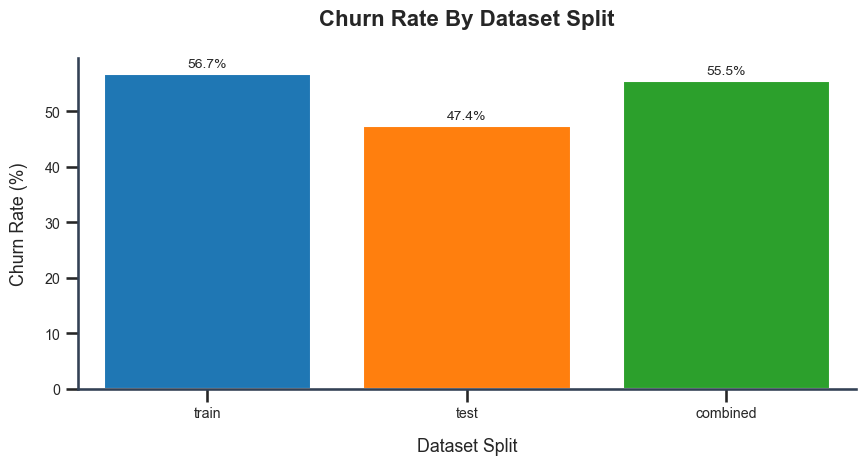

In [10]:
plot_churn_rate_by_split(combined_df)

## 5. Segment Analysis

The next sections turn the dataset into stakeholder-friendly customer segments so the retention story is easier to explain than raw feature values alone.

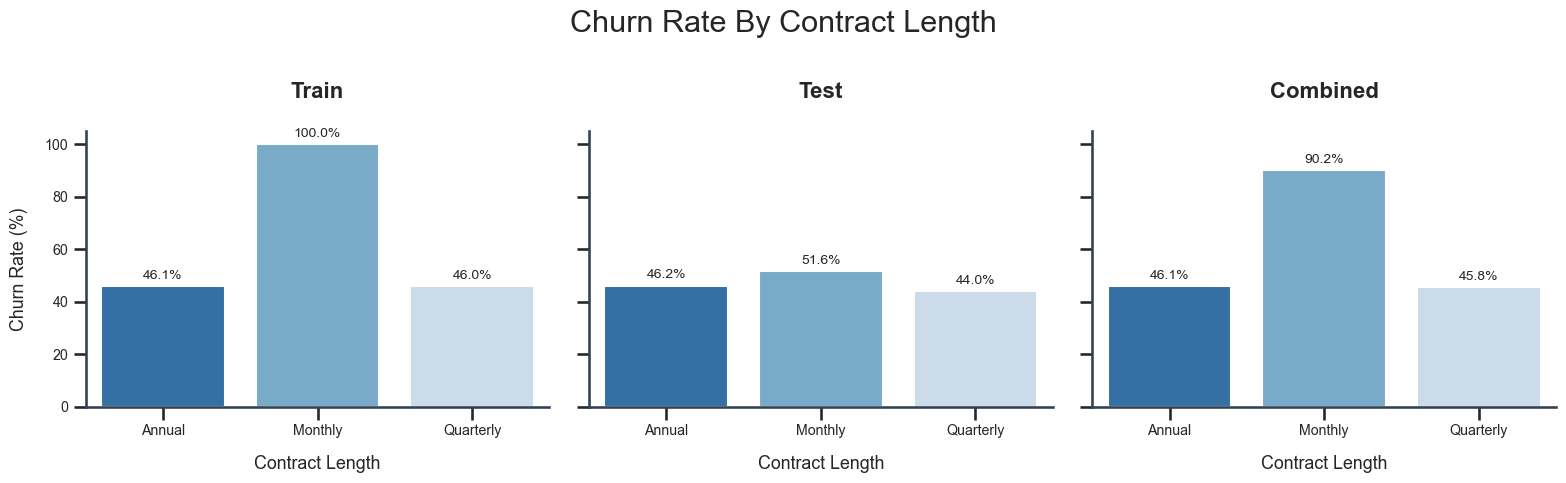

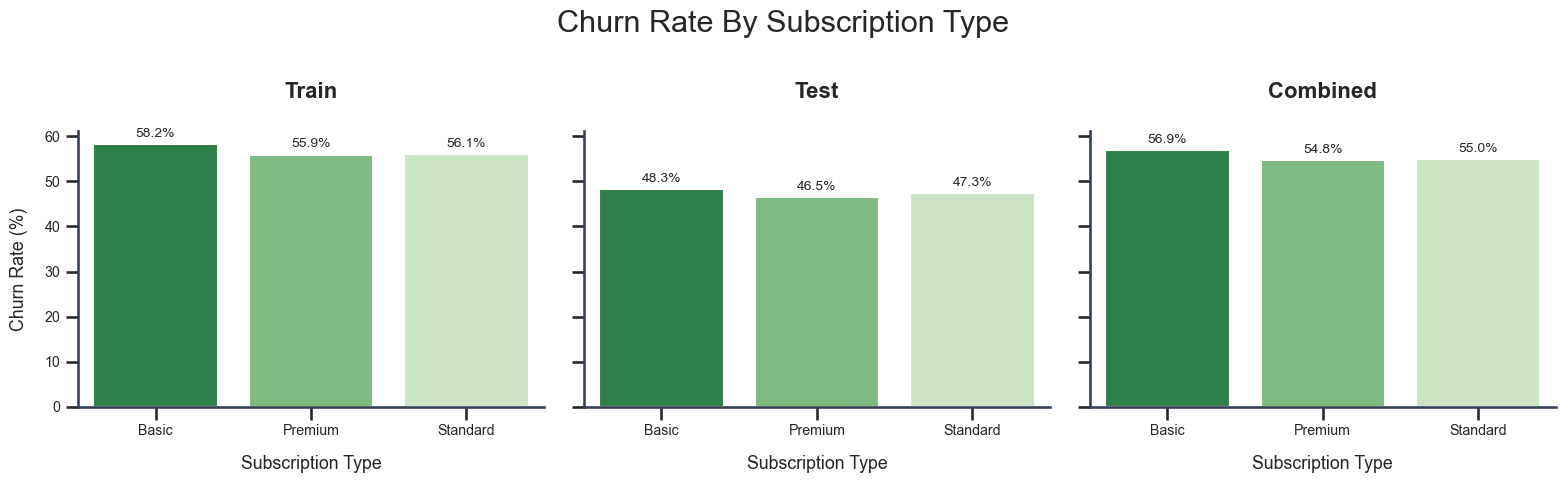

In [11]:
plot_churn_by_contract(combined_df)
plot_churn_by_subscription(combined_df)

array([<Axes: title={'center': 'Train'}, xlabel='Tenure Months', ylabel='Churn Rate (%)'>,
       <Axes: title={'center': 'Test'}, xlabel='Tenure Months'>,
       <Axes: title={'center': 'Combined'}, xlabel='Tenure Months'>],
      dtype=object)

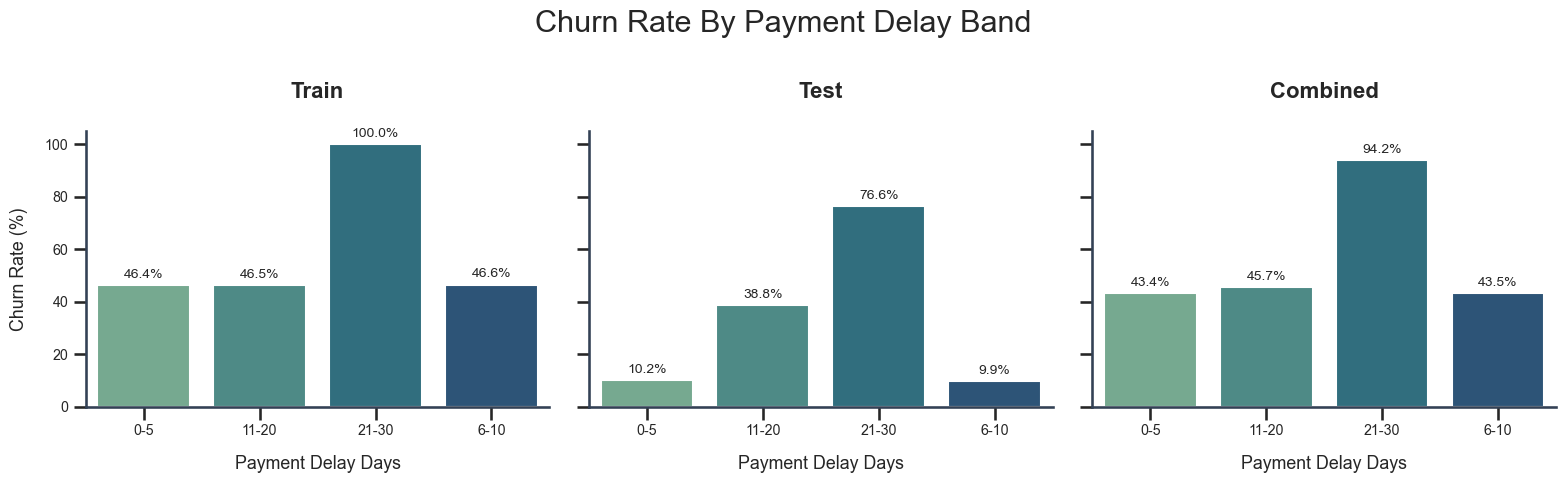

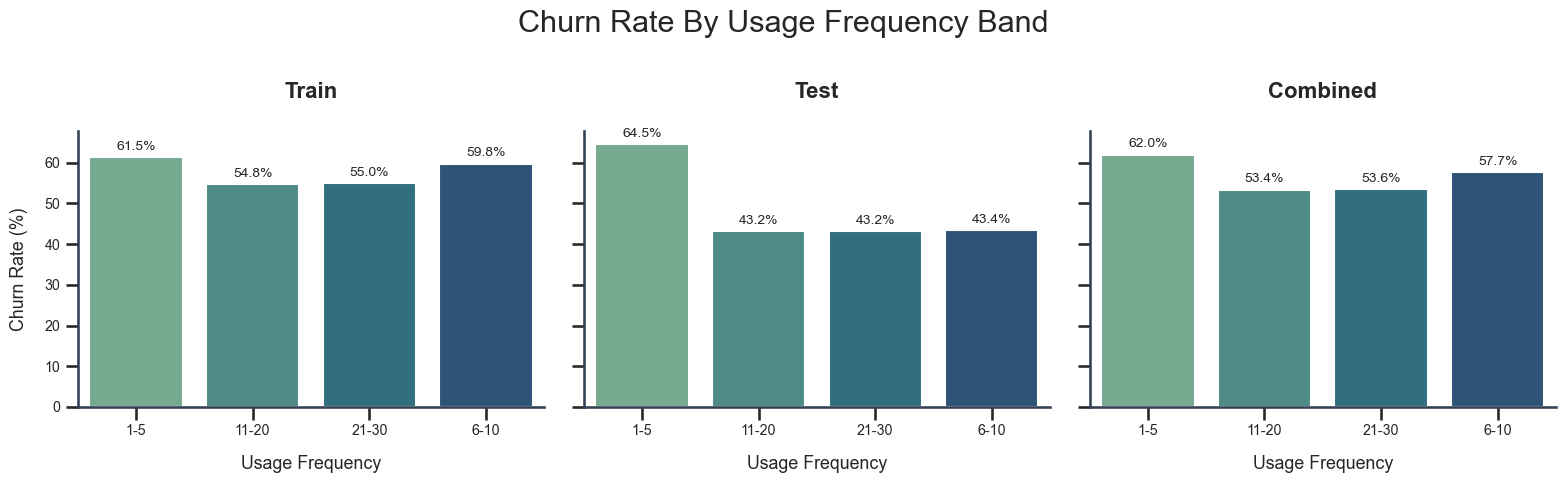

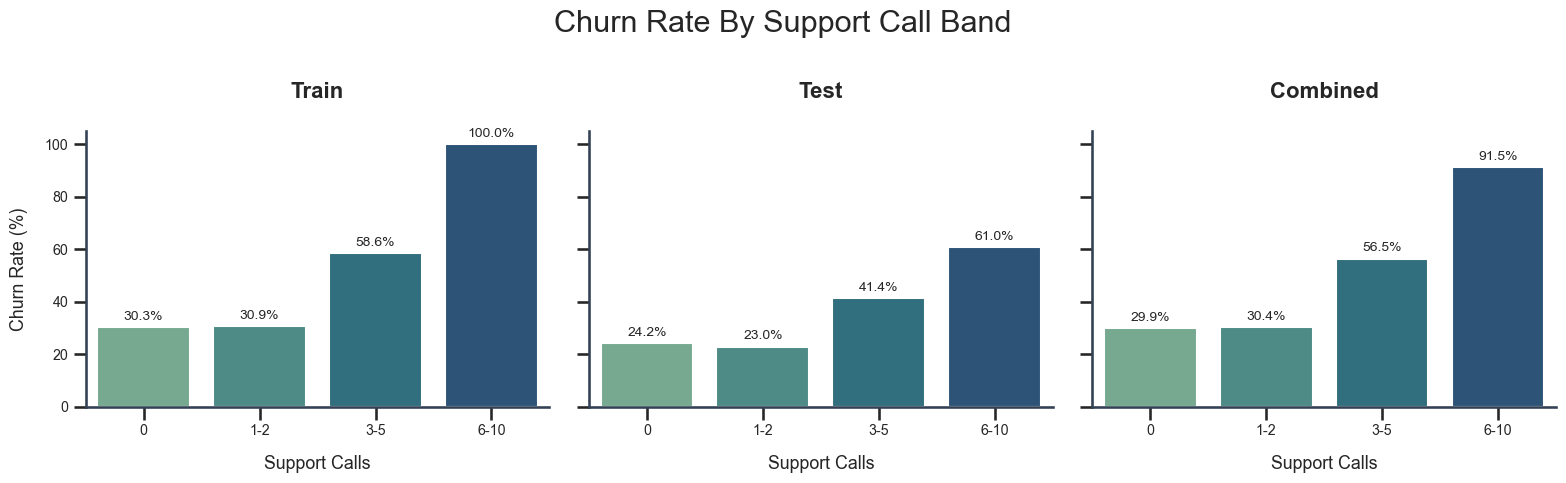

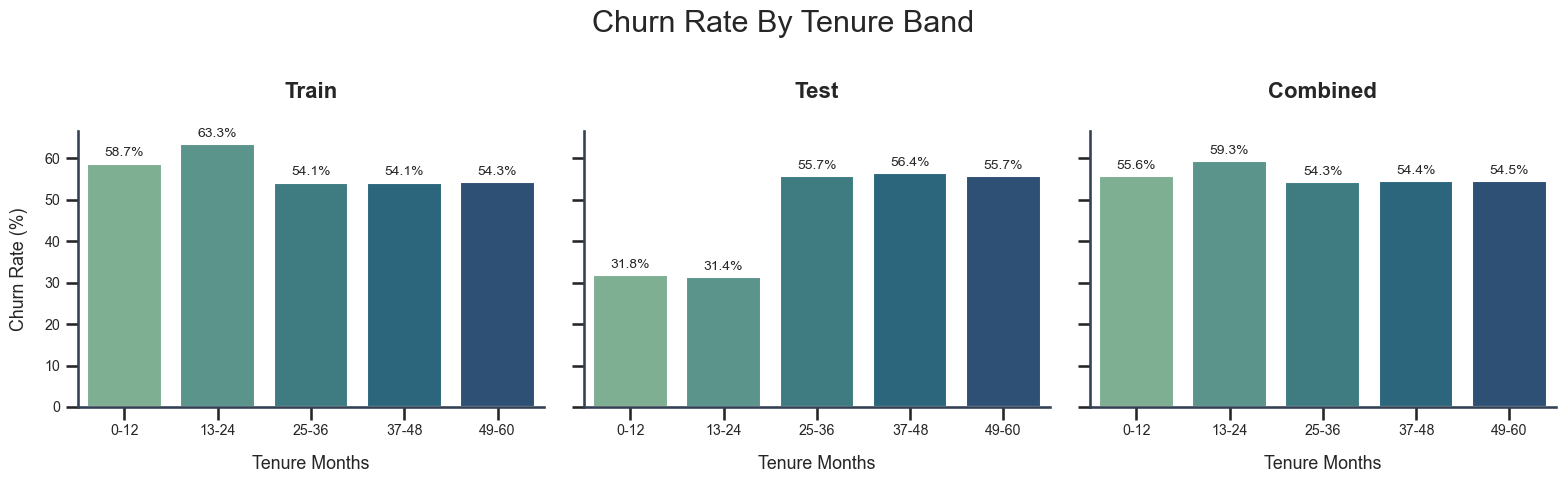

In [12]:
plot_churn_rate_by_numeric_bins(combined_df, "payment_delay_days", bins=[-1, 5, 10, 20, 30], labels=["0-5", "6-10", "11-20", "21-30"], title="Churn Rate By Payment Delay Band")
plot_churn_rate_by_numeric_bins(combined_df, "usage_frequency", bins=[0, 5, 10, 20, 30], labels=["1-5", "6-10", "11-20", "21-30"], title="Churn Rate By Usage Frequency Band")
plot_churn_rate_by_numeric_bins(combined_df, "support_calls", bins=[-1, 0, 2, 5, 10], labels=["0", "1-2", "3-5", "6-10"], title="Churn Rate By Support Call Band")
plot_churn_rate_by_numeric_bins(combined_df, "tenure_months", bins=[0, 12, 24, 36, 48, 60], labels=["0-12", "13-24", "25-36", "37-48", "49-60"], title="Churn Rate By Tenure Band")

## 6. Numeric Drivers

These views compare churned and retained customers directly, which helps separate business patterns from simple class-balance effects.

In [13]:
numeric_feature_summary(combined_df)

,churn_label,age,tenure_months,usage_frequency,support_calls,payment_delay_days,total_spend,last_interaction_days
0,Churned,41.870,31.020,15.300,5.280,15.990,538.900,15.590
1,Retained,37.000,31.760,16.230,2.030,10.380,721.390,13.390


In [14]:
correlation_table(combined_df)

support_calls            0.516
total_spend             -0.370
payment_delay_days       0.330
age                      0.191
last_interaction_days    0.127
usage_frequency         -0.053
tenure_months           -0.021
Name: churn, dtype: float64

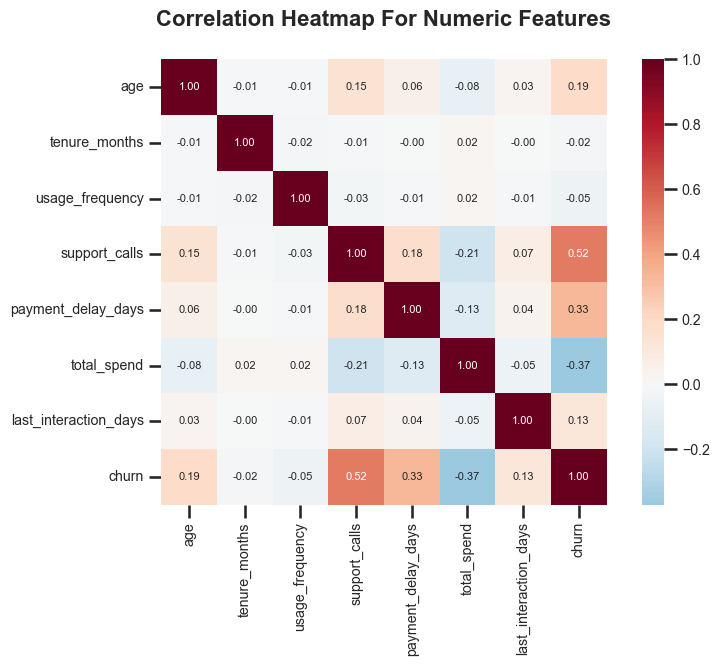

In [15]:
plot_correlation_heatmap(combined_df)

<Axes: title={'center': 'Total Spend By Churn Status'}, xlabel='Total Spend', ylabel='Churn Status'>

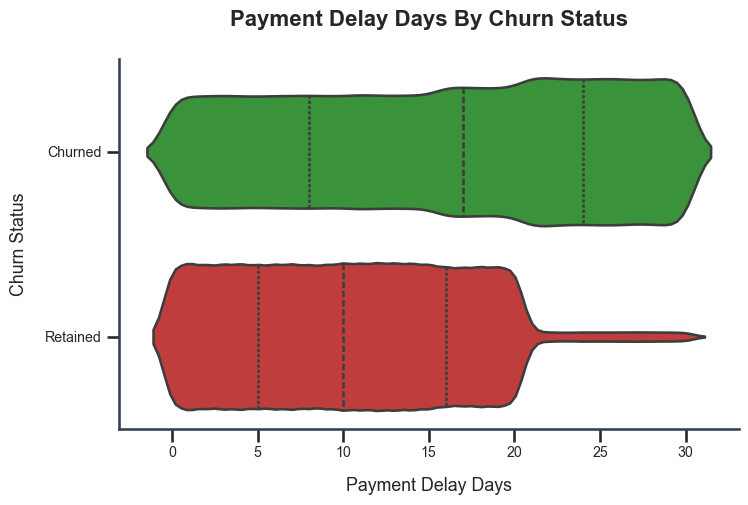

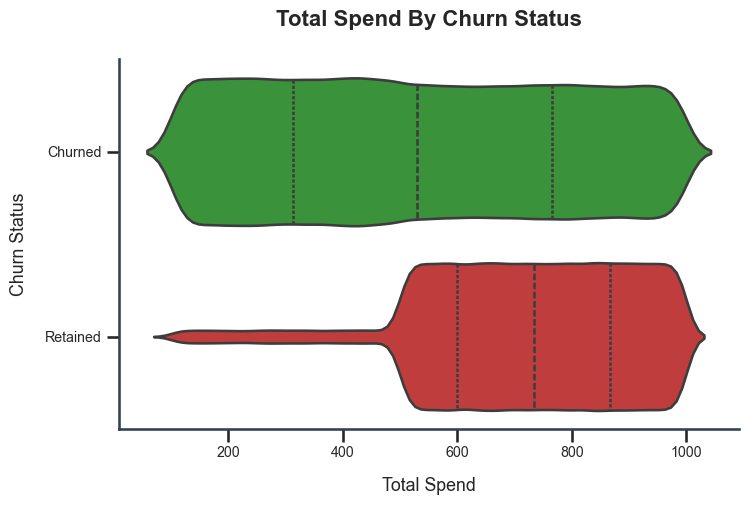

In [16]:
plot_numeric_feature_by_churn(combined_df, "payment_delay_days", kind="violin")
plot_numeric_feature_by_churn(combined_df, "total_spend", kind="violin")

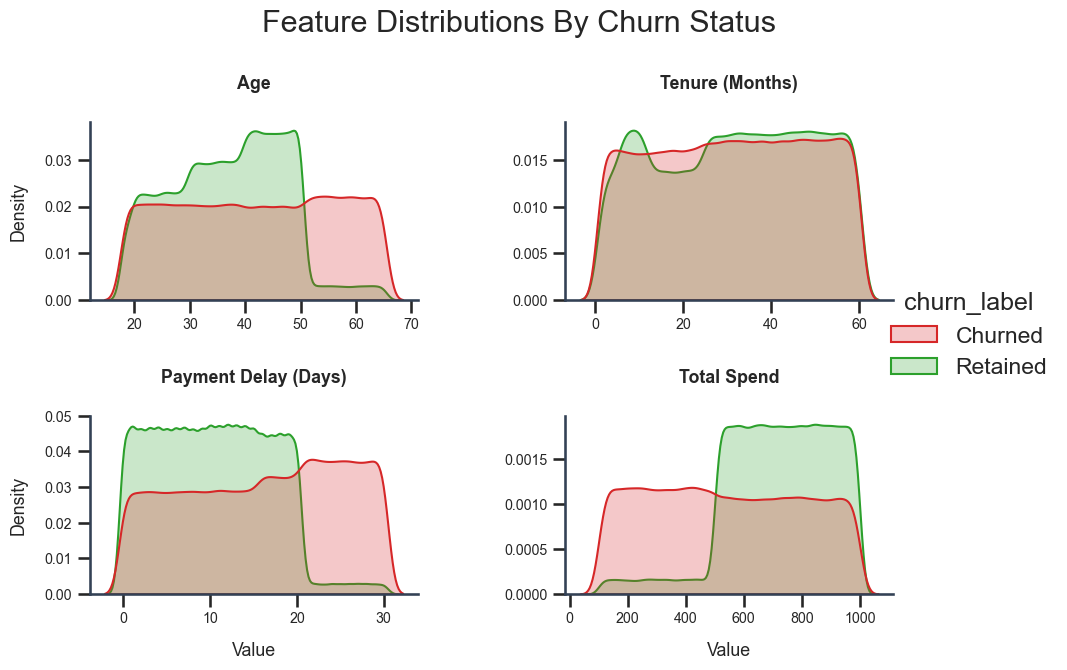

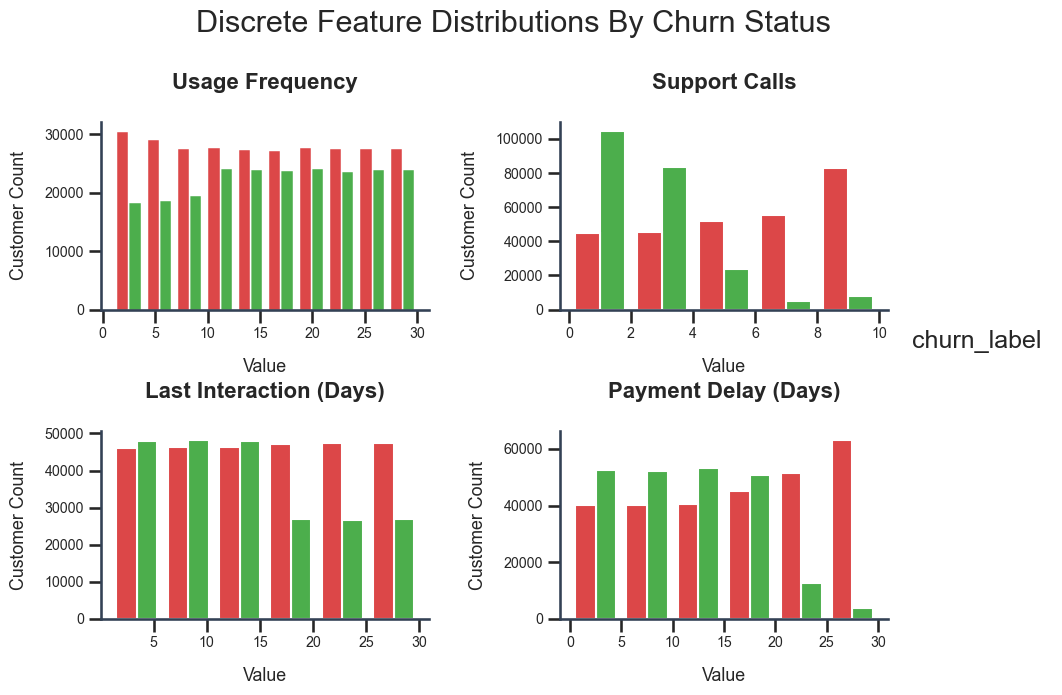

In [17]:
plot_numeric_distributions(
    combined_df,
    columns=["age", "tenure_months", "payment_delay_days", "total_spend"],
    kind="kde",
)
plot_numeric_distributions(
    combined_df,
    columns=["usage_frequency", "support_calls", "last_interaction_days", "payment_delay_days"],
    bins=[10, 5, 6, 6],
    kind="hist",
)

## 7. Interpretation

The strongest stakeholder-ready patterns in this dataset are the contract mix, payment-delay behaviour, support intensity, and churn concentration in specific customer buckets. The next step is to carry those patterns into the modelling notebook and test whether they improve predictive performance on the untouched test split.